In [3]:
import cv2
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. LOAD IMAGES
# =========================

ref = cv2.imread("ref.jpeg")
skew = cv2.imread("skew.jpeg")

if ref is None or skew is None:
    raise ValueError("Pastikan file 'ref.jpg' dan 'skew.jpg' ada di folder yang sama.")

ref_gray = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
skew_gray = cv2.cvtColor(skew, cv2.COLOR_BGR2GRAY)

# Samakan ukuran untuk evaluasi
h, w = ref_gray.shape
skew_gray = cv2.resize(skew_gray, (w, h))


# =========================
# 2. METRICS
# =========================

def mse(img1, img2):
    return np.mean((img1.astype("float") - img2.astype("float")) ** 2)

def psnr(img1, img2):
    mse_val = mse(img1, img2)
    if mse_val == 0:
        return 100
    return 10 * np.log10((255 ** 2) / mse_val)


# =========================
# 3. BASIC TRANSFORMATIONS
# =========================

def translation(img, tx, ty):
    M = np.array([
        [1, 0, tx],
        [0, 1, ty]
    ], dtype=np.float32)

    return cv2.warpAffine(img, M, (w, h))


def rotation(img, angle):
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))


def scaling(img, sx, sy):
    M = np.array([
        [sx, 0, 0],
        [0, sy, 0]
    ], dtype=np.float32)

    return cv2.warpAffine(img, M, (int(w * sx), int(h * sy)))


# =========================
# 4. AFFINE TRANSFORMATION
# =========================

def affine_transform(img):

    pts1 = np.float32([
        [50, 50],
        [w - 50, 50],
        [50, h - 50]
    ])

    pts2 = np.float32([
        [10, 100],
        [w - 100, 50],
        [100, h - 50]
    ])

    M = cv2.getAffineTransform(pts1, pts2)

    return cv2.warpAffine(img, M, (w, h))


# =========================
# 5. PERSPECTIVE TRANSFORMATION
# =========================

def perspective_transform(img, interpolation_method):

    pts1 = np.float32([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1]
    ])

    pts2 = np.float32([
        [50, 50],
        [w - 50, 20],
        [w - 20, h - 50],
        [20, h - 20]
    ])

    H = cv2.getPerspectiveTransform(pts1, pts2)

    # PERBAIKAN DI SINI → flags sebagai positional argument
    return cv2.warpPerspective(
        img,
        H,
        (w, h),
        None,
        None,
        interpolation_method
    )


# =========================
# 6. INTERPOLATION EXPERIMENT
# =========================

results = []

interpolations = {
    "Nearest": cv2.INTER_NEAREST,
    "Bilinear": cv2.INTER_LINEAR,
    "Bicubic": cv2.INTER_CUBIC
}

for name, method in interpolations.items():

    start = time.time()
    transformed = perspective_transform(skew_gray, method)
    end = time.time()

    mse_val = mse(ref_gray, transformed)
    psnr_val = psnr(ref_gray, transformed)
    elapsed = end - start

    results.append([name, mse_val, psnr_val, elapsed])

    cv2.imwrite(f"output_{name}.jpg", transformed)


# =========================
# 7. SAVE & DISPLAY RESULTS
# =========================

df = pd.DataFrame(results,
                  columns=["Interpolation", "MSE", "PSNR", "Time (s)"])

print("\n=== Evaluation Results ===")
print(df)

df.to_csv("evaluation_results.csv", index=False)

print("\nOutput images saved:")
print("- output_Nearest.jpg")
print("- output_Bilinear.jpg")
print("- output_Bicubic.jpg")
print("- evaluation_results.csv")


=== Evaluation Results ===
  Interpolation          MSE       PSNR  Time (s)
0       Nearest  3845.438219  12.281345  0.003847
1      Bilinear  2663.683780  13.875977  0.003417
2       Bicubic  2659.006984  13.883609  0.004798

Output images saved:
- output_Nearest.jpg
- output_Bilinear.jpg
- output_Bicubic.jpg
- evaluation_results.csv


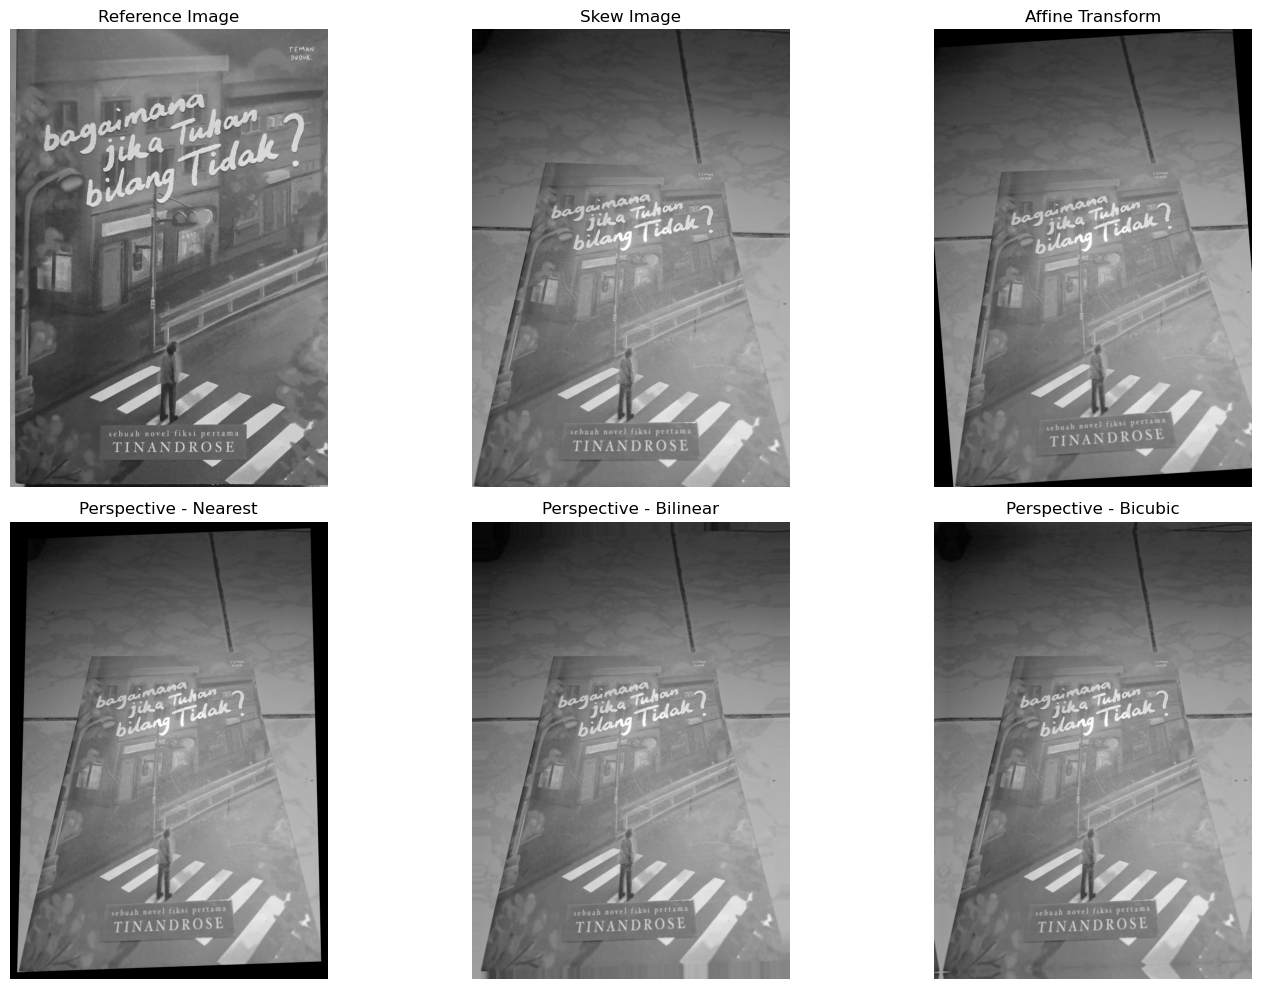

In [4]:
# =========================
# 8. VISUALIZATION
# =========================

# Load kembali hasil transformasi untuk visualisasi
img_nearest = cv2.imread("output_Nearest.jpg", 0)
img_bilinear = cv2.imread("output_Bilinear.jpg", 0)
img_bicubic = cv2.imread("output_Bicubic.jpg", 0)

plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(ref_gray, cmap='gray')
plt.title("Reference Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(skew_gray, cmap='gray')
plt.title("Skew Image")
plt.axis("off")

plt.subplot(2,3,3)
affine_img = affine_transform(skew_gray)
plt.imshow(affine_img, cmap='gray')
plt.title("Affine Transform")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(img_nearest, cmap='gray')
plt.title("Perspective - Nearest")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(img_bilinear, cmap='gray')
plt.title("Perspective - Bilinear")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(img_bicubic, cmap='gray')
plt.title("Perspective - Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

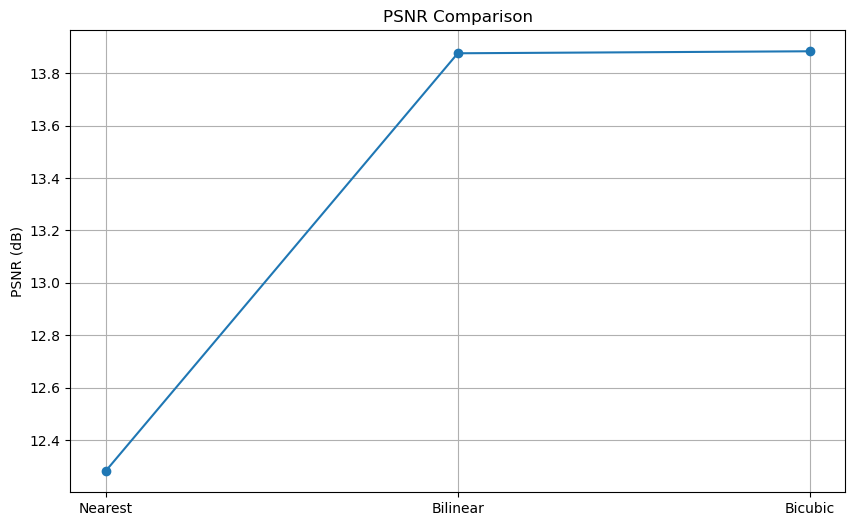

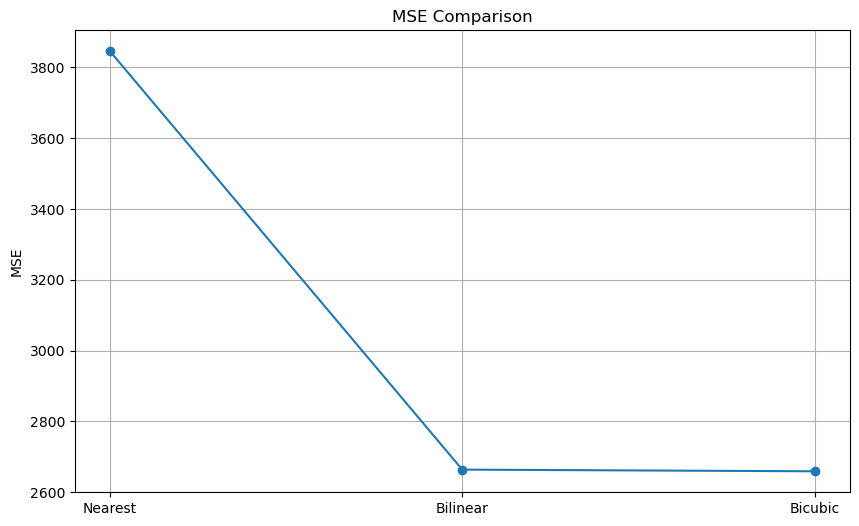

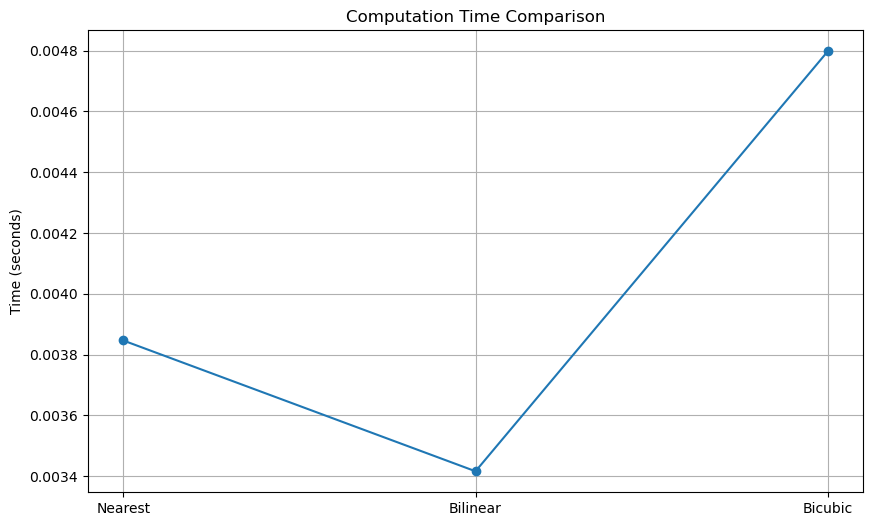

In [5]:
# =========================
# 9. METRIC VISUALIZATION
# =========================

plt.figure(figsize=(10,6))

plt.plot(df["Interpolation"], df["PSNR"], marker='o')
plt.title("PSNR Comparison")
plt.ylabel("PSNR (dB)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

plt.plot(df["Interpolation"], df["MSE"], marker='o')
plt.title("MSE Comparison")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

plt.plot(df["Interpolation"], df["Time (s)"], marker='o')
plt.title("Computation Time Comparison")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()